---
title: "Лабораторна робота №2. Статистичні закономірності текстових даних"
description: "Технології аналізу текстової інформації та машинне навчання | КрНУ ім. М. Остроградського"
author: "&copy; Роменський В'ячеслав, 2026"
date: today
lang: uk
jupyter: python3

format:
  html:
    toc: true
    toc-location: right
    number-sections: false
    code-fold: true
    embed-resources: true
    self-contained-math: true
---


::: callout-note
## Примітка

Для виконання роботи потрібно опрацювати *лекцію 3* та мати налаштоване Python/DS-середовище з бібліотеками *pandas*, *numpy* та *matplotlib*.  
Зошит побудовано так, щоб його можна було виконати навіть без зовнішнього датасету: якщо власний корпус відсутній, використовується вбудований навчальний набір текстів.
:::


## Мета роботи

Опанувати методи частотного та інформаційного аналізу текстового корпусу: побудову частотного словника, рангових розподілів, перевірку наближення до закону Ципфа, дослідження зростання словника за законом Хіпса та обчислення ентропійних характеристик тексту.


## Що я буду вміти після виконання роботи?

Після виконання лабораторної роботи ти будеш вміти:

- формувати невеликий навчальний корпус для статистичного аналізу;
- виконувати токенізацію та базову нормалізацію тексту;
- будувати абсолютні та відносні частоти токенів;
- створювати ранговий частотний словник;
- аналізувати емпіричний розподіл частот у термінах закону Ципфа;
- досліджувати зростання словника у термінах закону Хіпса;
- обчислювати ентропію Шеннона для текстового корпусу;
- інтерпретувати статистичні характеристики текстів у прикладному NLP-контексті.


## Теоретичні відомості

У межах лекції 3 текст розглядався не лише як мовний об'єкт, а і як *джерело статистичних закономірностей*.  
Для реальних корпусів характерні такі властивості:

1. у тексті існує невелика кількість дуже частотних слів і довгий хвіст рідкісної лексики;
2. частота слова пов'язана з його рангом у частотному словнику;
3. зі зростанням обсягу корпусу словник теж зростає, але *сублінійно*;
4. розподіл імовірностей слів дозволяє оцінювати інформаційну різноманітність тексту.

Базова схема цієї лабораторної роботи:

`Corpus → Cleaning / Tokenization → Frequency dictionary → Rank distribution → Zipf / Heaps / Entropy → Interpretation`

У цій роботі ми переходимо від результатів лабораторної роботи 1 до кількісного аналізу корпусу.


## Постановка завдання

Потрібно сформувати *навчальний корпус текстів* і виконати для нього такі кроки:

1. підготувати корпус до аналізу;
2. побудувати частотний словник;
3. розрахувати абсолютні та відносні частоти;
4. сформувати ранговий розподіл;
5. порівняти емпіричний розподіл із ідеєю закону Ципфа;
6. дослідити зростання словника під час нарощування корпусу;
7. обчислити ентропію Шеннона;
8. зробити змістовні висновки щодо структури корпусу.

У роботі передбачено *базову частину* з вбудованим корпусом і *індивідуальну частину*, куди студент може додати власні тексти.


In [5]:
# Базові імпорти
import math
import re
from collections import Counter
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


## 1. Формування корпусу

Нижче наведено невеликий навчальний корпус українською мовою. Було додано до корпусу 20 текстів на тему текст майнінгу та машинного навчання.


In [28]:
base_corpus = [
    "Аналіз текстових даних дає змогу виявляти закономірності у великих масивах документів.",
    "Частотний словник відображає структуру корпусу та допомагає оцінити розподіл лексики.",
    "У задачах text mining важливо поєднувати мовну інтерпретацію та математичні моделі.",
    "Модель Bag of Words ігнорує порядок слів, але добре працює як базове представлення тексту.",
    "TF IDF зменшує вагу надто частотних слів і підсилює інформативні терміни документа.",
    "Статистичні закономірності тексту лежать в основі класифікації, кластеризації та пошуку документів.",
    "Ентропія тексту характеризує різноманітність лексики та ступінь інформаційної невизначеності.",
    "Закон Ципфа описує зв'язок між частотою слова і його рангом у природномовному корпусі.",
    "Закон Хіпса показує, що словник корпусу зростає повільніше, ніж кількість токенів.",
    "Попередня обробка тексту впливає на якість частотного аналізу і подальшого моделювання."
]

student_corpus = [
    "Текст майнінг використовується для автоматичного аналізу великих обсягів документів.",
    "Машинне навчання допомагає класифікувати тексти за темами та категоріями.",
    "Аналіз тональності дозволяє визначати позитивні або негативні відгуки клієнтів.",
    "Текст майнінг широко застосовується для виявлення ключових слів у статтях.",
    "Алгоритми машинного навчання можуть прогнозувати поведінку користувачів за текстовими даними.",
    "Обробка природної мови є важливою складовою сучасних систем аналізу тексту.",
    "Нейронні мережі використовуються для перекладу текстів між різними мовами.",
    "Текст майнінг допомагає компаніям вивчати думку споживачів у соціальних мережах.",
    "Моделі машинного навчання можуть автоматично виявляти спам у електронній пошті.",
    "Векторизація тексту перетворює слова у числові ознаки для аналізу.",
    "Тематичне моделювання дозволяє знаходити приховані теми у документах.",
    "Текст майнінг використовується у медицині для аналізу наукових публікацій.",
    "Рекомендаційні системи застосовують машинне навчання для персоналізації контенту.",
    "Автоматичне резюмування текстів допомагає швидко отримувати головну інформацію.",
    "Машинне навчання використовується для розпізнавання шахрайських повідомлень.",
    "Текст майнінг дозволяє аналізувати новини та виявляти інформаційні тренди.",
    "Глибоке навчання покращує якість розпізнавання змісту складних текстів.",
    "Чат-боти використовують обробку мови для спілкування з користувачами.",
    "Аналіз частоти слів допомагає знаходити найважливіші поняття у текстах.",
    "Поєднання текст майнінгу та машинного навчання відкриває нові можливості для бізнесу."
]

corpus = base_corpus + student_corpus
print(f"Загальна кількість документів у корпусі: {len(corpus)}")


Загальна кількість документів у корпусі: 30


## 2. Очищення тексту

Для створення однорідного тексту було виконано очищення тексту, що включає зведення тексту до нижнього регістру, заміни схожих символів на один єдиний варіант (наприклад, апостроф), прибирання спеціальних символів, цифр, підкреслень, дефісів, слешів та зайвих пробілів.

In [29]:
def clean_text(text: str) -> str:
    text = text.lower()
    text = text.replace("’", "'").replace("`", "'")
    text = re.sub(r"[-_/]", " ", text)
    text = re.sub(r"[^\w\s']", " ", text, flags=re.UNICODE)
    text = re.sub(r"\d+", " ", text)
    text = re.sub(r"_+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

clean_corpus = [clean_text(text) for text in corpus]

clean_corpus[-5:]


['текст майнінг дозволяє аналізувати новини та виявляти інформаційні тренди',
 'глибоке навчання покращує якість розпізнавання змісту складних текстів',
 'чат боти використовують обробку мови для спілкування з користувачами',
 'аналіз частоти слів допомагає знаходити найважливіші поняття у текстах',
 'поєднання текст майнінгу та машинного навчання відкриває нові можливості для бізнесу']

## 3. Токенізація та базова фільтрація, стемінг

Було проведено три єтапи: токенізація, очищення від стоп-слів та стемінг. 
Буде перевірено два варіанти корпусів:
- тільки токенізований;
- токенізований, очищений та із прибраними закінченнями.

In [9]:
def tokenize(text: str) -> list[str]:
    return [token for token in text.split() if len(token) >= 2]

tokenized_corpus = [tokenize(text) for text in clean_corpus]

tokenized_corpus[-1]


['поєднання',
 'текст',
 'майнінгу',
 'та',
 'машинного',
 'навчання',
 'відкриває',
 'нові',
 'можливості',
 'для',
 'бізнесу']

### Видалення частини стоп-слів

Для частотного аналізу корисно порівнювати результати *зі стоп-словами* і *без стоп-слів*.  
Нижче наведено компактний список поширених українських службових слів.


In [10]:
uk_stopwords = {
    "і", "й", "та", "а", "але", "або", "що", "це", "у", "в", "до", "на", "за",
    "із", "з", "як", "для", "не", "по", "про", "при", "від", "над", "під",
    "то", "же", "чи", "його", "її", "їх", "бути",
    "між", "тому", "тоді", "ж"
}

filtered_corpus = [
    [token for token in doc if token not in uk_stopwords]
    for doc in tokenized_corpus
]

filtered_corpus[-3:]


[['чат',
  'боти',
  'використовують',
  'обробку',
  'мови',
  'спілкування',
  'користувачами'],
 ['аналіз',
  'частоти',
  'слів',
  'допомагає',
  'знаходити',
  'найважливіші',
  'поняття',
  'текстах'],
 ['поєднання',
  'текст',
  'майнінгу',
  'машинного',
  'навчання',
  'відкриває',
  'нові',
  'можливості',
  'бізнесу']]

### Стемінг
Далі було створено просту функцію для видалення закінчень, аби звести слова до їх основ. Цей крок був доданий для того, аби знайти більш точні дані щодо частоти появи різних слів.

In [11]:
def simple_stem(word):
    suffixes = ["ами","ями","ів","ий","а","у","ою","е","и","і","ів","ів","ими"]
    for suf in suffixes:
        if word.endswith(suf):
            return word[:-len(suf)]
    return word

stemmed_corpus = [
    [simple_stem(token) for token in doc]
    for doc in filtered_corpus
]

stemmed_corpus[-3:]

[['чат',
  'бот',
  'використовують',
  'обробк',
  'мов',
  'спілкування',
  'користувач'],
 ['аналіз',
  'частот',
  'сл',
  'допомагає',
  'знаходит',
  'найважливіш',
  'поняття',
  'текстах'],
 ['поєднання',
  'текст',
  'майнінг',
  'машинного',
  'навчання',
  'відкриває',
  'нов',
  'можливост',
  'бізнес']]

## 4. Аналіз та порівняння корпусів за базовими ознаками

Вже можна помітити, як сильно впав і розмір словнику (через стемінг), і кількість токенів (через видалення стоп-слів).

In [39]:
def create_stats_df(analysis_corpus):
    doc_lengths = [len(doc) for doc in analysis_corpus]
    all_tokens = [token for doc in analysis_corpus for token in doc]
    vocabulary = sorted(set(all_tokens))
    N = len(all_tokens)
    V = len(vocabulary)
    ttr = V / N if N else 0

    stats_df = pd.DataFrame(
        {
            "Показник": [
                "Кількість документів",
                "Загальна кількість токенів N",
                "Розмір словника V",
                "Середня довжина документа",
                "Мінімальна довжина документа",
                "Максимальна довжина документа",
                "Type-Token Ratio (V/N)",
            ],
            "Значення": [
                len(analysis_corpus),
                N,
                V,
                round(np.mean(doc_lengths), 2) if doc_lengths else 0,
                min(doc_lengths) if doc_lengths else 0,
                max(doc_lengths) if doc_lengths else 0,
                round(ttr, 4),
            ],
        }
    )

    return stats_df

print("Корпус 1:")
display(create_stats_df(tokenized_corpus))

print("Корпус 2:")
display(create_stats_df(stemmed_corpus))

Корпус 1:


,Показник,Значення
0,Кількість документів,30.0000
1,Загальна кількість токенів N,278.0000
2,Розмір словника V,200.0000
3,Середня довжина документа,9.2700
4,Мінімальна довжина документа,7.0000
5,Максимальна довжина документа,14.0000
6,Type-Token Ratio (V/N),0.7194


Корпус 2:


,Показник,Значення
0,Кількість документів,30.0000
1,Загальна кількість токенів N,252.0000
2,Розмір словника V,177.0000
3,Середня довжина документа,8.4000
4,Мінімальна довжина документа,6.0000
5,Максимальна довжина документа,12.0000
6,Type-Token Ratio (V/N),0.7024


## 5. Побудова частотного словників

Частотний словник ставить у відповідність кожному токену кількість його входжень у корпус.
Явно видно те, що набагато важче витягнути контекст саме із даних про перший корпус - багато високочастотних слів не несуть великого сенсового навантаження самі со побі.


In [47]:
def create_counter_df(analysis_corpus):
    all_tokens = [token for doc in analysis_corpus for token in doc]
    token_counter = Counter(all_tokens)

    freq_df = (
        pd.DataFrame(token_counter.items(), columns=["token", "abs_freq"])
        .sort_values(by=["abs_freq", "token"], ascending=[False, True])
        .reset_index(drop=True)
    )

    freq_df["rel_freq"] = freq_df["abs_freq"] / freq_df["abs_freq"].sum()
    freq_df["rank"] = np.arange(1, len(freq_df) + 1)

    return freq_df

print("Корпус 1:")
freq_df_1 = create_counter_df(tokenized_corpus)
display(freq_df_1.head(15))

print("Корпус 2:")
freq_df_2 = create_counter_df(stemmed_corpus)
display(freq_df_2.head(15))


Корпус 1:


,token,abs_freq,rel_freq,rank
0,для,9,0.032374,1
1,навчання,7,0.025180,2
2,та,7,0.025180,3
3,текст,6,0.021583,4
4,тексту,6,0.021583,5
5,аналізу,5,0.017986,6
6,допомагає,5,0.017986,7
7,майнінг,5,0.017986,8
8,слів,4,0.014388,9
9,аналіз,3,0.010791,10


Корпус 2:


,token,abs_freq,rel_freq,rank
0,текст,16,0.063492,1
1,аналіз,8,0.031746,2
2,навчання,7,0.027778,3
3,майнінг,6,0.023810,4
4,допомагає,5,0.019841,5
5,документ,4,0.015873,6
6,сл,4,0.015873,7
7,використовується,3,0.011905,8
8,виявлят,3,0.011905,9
9,дозволяє,3,0.011905,10


## 6. Візуалізація частотного словника

Для наочності побудуємо стовпчикову діаграму найчастотніших токенів. Для першого корпусу розподіл більш схожий на лінійний, ніж для другого. Це вказує на більшу кількість частих слів, які використовуються майже в кожному тексті, тому мають схожу кількість появи. На другому графіку спад відбувається різко за допомогою прибирання зайвих слів та перетворення схожих слів у однакові токени.


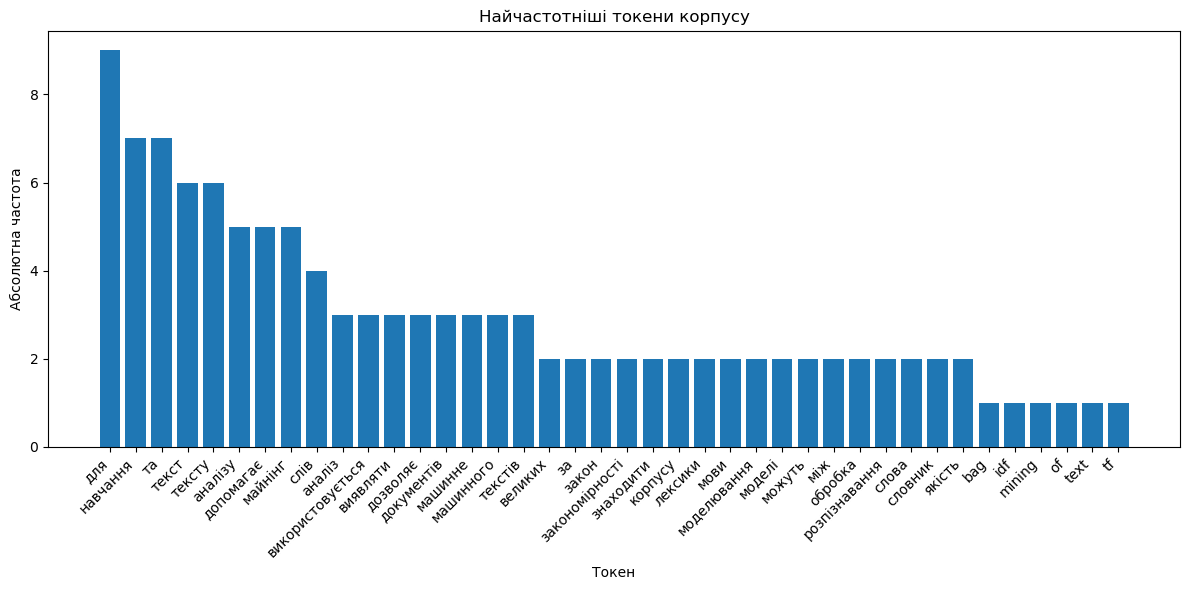

In [49]:
top_freq_df_1 = freq_df_1.head(40)

plt.figure(figsize=(12, 6))
plt.bar(top_freq_df_1["token"], top_freq_df_1["abs_freq"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Токен")
plt.ylabel("Абсолютна частота")
plt.title("Найчастотніші токени корпусу")
plt.tight_layout()
plt.show()


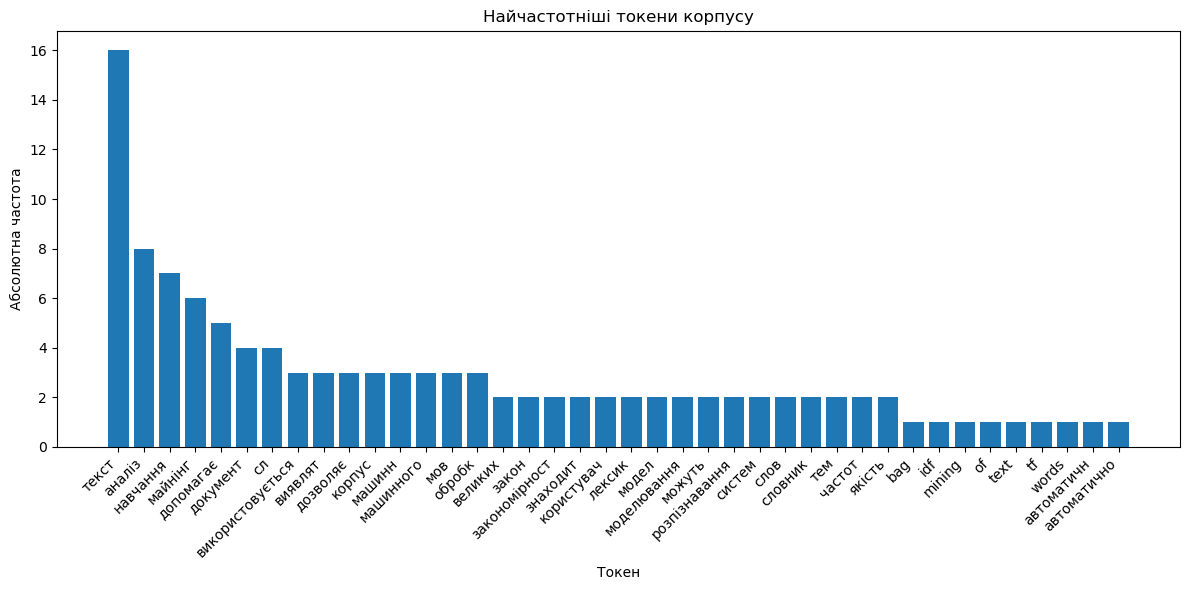

In [50]:
top_freq_df_2 = freq_df_2.head(40)

plt.figure(figsize=(12, 6))
plt.bar(top_freq_df_2["token"], top_freq_df_2["abs_freq"])
plt.xticks(rotation=45, ha="right")
plt.xlabel("Токен")
plt.ylabel("Абсолютна частота")
plt.title("Найчастотніші токени корпусу")
plt.tight_layout()
plt.show()

## 7. Ранговий розподіл і закон Ципфа

Закон Ципфа стверджує, що частота слова приблизно обернено пропорційна його рангу:

$$
f(r) \propto \frac{1}{r^\alpha}.
$$

Для грубої емпіричної перевірки:

1. будуємо ранговий розподіл;
2. аналізуємо його на логарифмічних шкалах;
3. оцінюємо, наскільки він наближений до степеневої залежності.


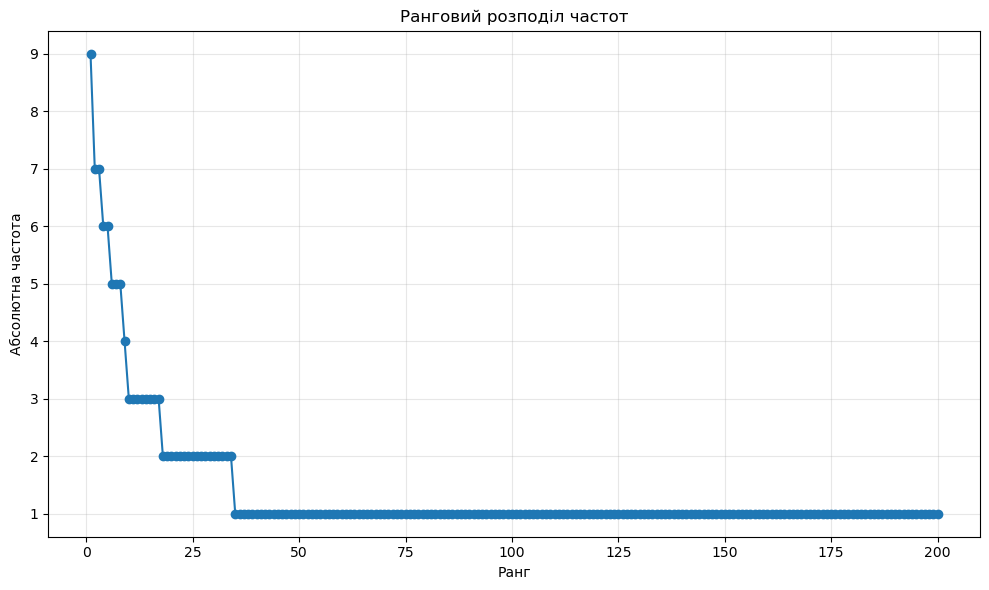

In [52]:
plt.figure(figsize=(10, 6))
plt.plot(freq_df_1["rank"], freq_df_1["abs_freq"], marker="o", linestyle="-")
plt.xlabel("Ранг")
plt.ylabel("Абсолютна частота")
plt.title("Ранговий розподіл частот")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


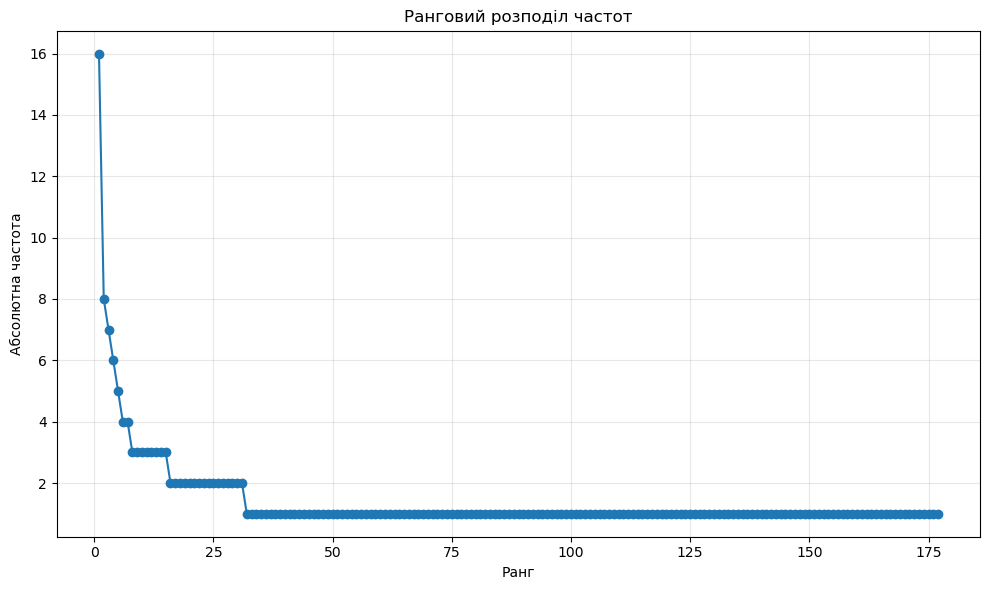

In [51]:
plt.figure(figsize=(10, 6))
plt.plot(freq_df_2["rank"], freq_df_2["abs_freq"], marker="o", linestyle="-")
plt.xlabel("Ранг")
plt.ylabel("Абсолютна частота")
plt.title("Ранговий розподіл частот")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### Лог-лог подання рангового розподілу

У логарифмічних координатах розподіл, близький до закону Ципфа, часто набуває вигляду майже прямої лінії. За оцінкою нахилу прямої, графіки майже однакові, але другий трохи більш наближений до закону Ципфа.


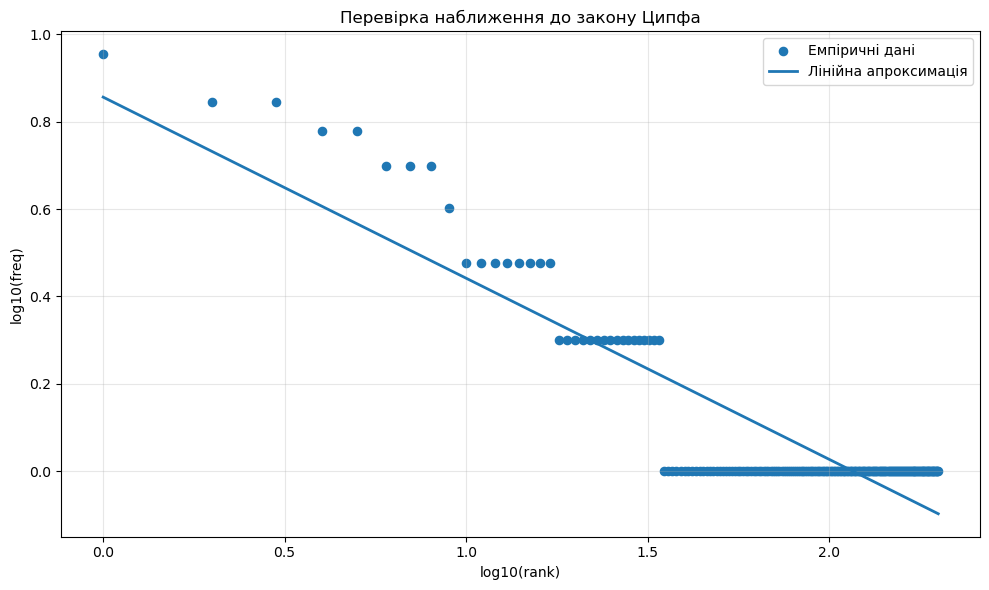

Оцінений нахил прямої: -0.415
Для закону Ципфа нахил зазвичай близький до -1.


In [56]:
zipf_df = freq_df_1[freq_df_1["abs_freq"] > 0].copy()
zipf_df["log_rank"] = np.log10(zipf_df["rank"])
zipf_df["log_freq"] = np.log10(zipf_df["abs_freq"])

coef = np.polyfit(zipf_df["log_rank"], zipf_df["log_freq"], 1)
slope, intercept = coef
zipf_df["fitted_log_freq"] = slope * zipf_df["log_rank"] + intercept

plt.figure(figsize=(10, 6))
plt.scatter(zipf_df["log_rank"], zipf_df["log_freq"], s=35, label="Емпіричні дані")
plt.plot(zipf_df["log_rank"], zipf_df["fitted_log_freq"], linewidth=2, label="Лінійна апроксимація")
plt.xlabel("log10(rank)")
plt.ylabel("log10(freq)")
plt.title("Перевірка наближення до закону Ципфа")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Оцінений нахил прямої: {slope:.3f}")
print("Для закону Ципфа нахил зазвичай близький до -1.")


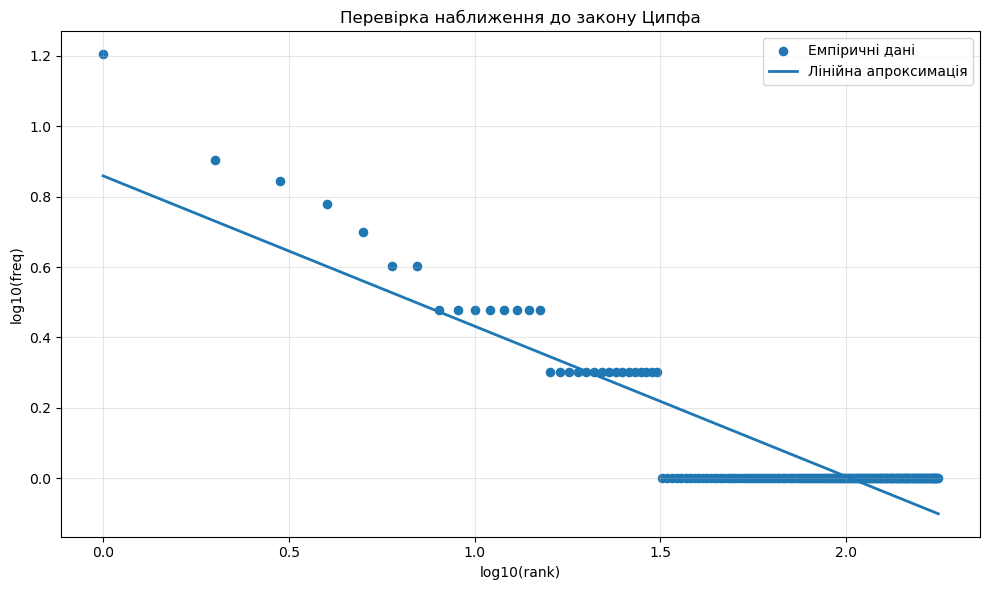

Оцінений нахил прямої: -0.427
Для закону Ципфа нахил зазвичай близький до -1.


In [57]:
zipf_df = freq_df_2[freq_df_2["abs_freq"] > 0].copy()
zipf_df["log_rank"] = np.log10(zipf_df["rank"])
zipf_df["log_freq"] = np.log10(zipf_df["abs_freq"])

coef = np.polyfit(zipf_df["log_rank"], zipf_df["log_freq"], 1)
slope, intercept = coef
zipf_df["fitted_log_freq"] = slope * zipf_df["log_rank"] + intercept

plt.figure(figsize=(10, 6))
plt.scatter(zipf_df["log_rank"], zipf_df["log_freq"], s=35, label="Емпіричні дані")
plt.plot(zipf_df["log_rank"], zipf_df["fitted_log_freq"], linewidth=2, label="Лінійна апроксимація")
plt.xlabel("log10(rank)")
plt.ylabel("log10(freq)")
plt.title("Перевірка наближення до закону Ципфа")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Оцінений нахил прямої: {slope:.3f}")
print("Для закону Ципфа нахил зазвичай близький до -1.")


### Порівняння емпіричних та теоретичних частот

За частотами другий корпус виглядає набагато краще, бо не має зайвих дуже частих слів.


In [59]:
def create_comparison_df(freq_df):
    comparison_zipf_df = freq_df[["rank", "token", "abs_freq", "zipf_theoretical"]].head(15).copy()
    comparison_zipf_df["zipf_theoretical"] = comparison_zipf_df["zipf_theoretical"].round(3)
    return comparison_zipf_df

C = freq_df_1.loc[0, "abs_freq"]
freq_df_1["zipf_theoretical"] = C / freq_df_1["rank"]
print("Корпус 1")
display(create_comparison_df(freq_df_1))

C = freq_df_2.loc[0, "abs_freq"]
freq_df_2["zipf_theoretical"] = C / freq_df_2["rank"]
print("Корпус 2")
display(create_comparison_df(freq_df_2))


Корпус 1


,rank,token,abs_freq,zipf_theoretical
0,1,для,9,9.000
1,2,навчання,7,4.500
2,3,та,7,3.000
3,4,текст,6,2.250
4,5,тексту,6,1.800
5,6,аналізу,5,1.500
6,7,допомагає,5,1.286
7,8,майнінг,5,1.125
8,9,слів,4,1.000
9,10,аналіз,3,0.900


Корпус 2


,rank,token,abs_freq,zipf_theoretical
0,1,текст,16,16.000
1,2,аналіз,8,8.000
2,3,навчання,7,5.333
3,4,майнінг,6,4.000
4,5,допомагає,5,3.200
5,6,документ,4,2.667
6,7,сл,4,2.286
7,8,використовується,3,2.000
8,9,виявлят,3,1.778
9,10,дозволяє,3,1.600


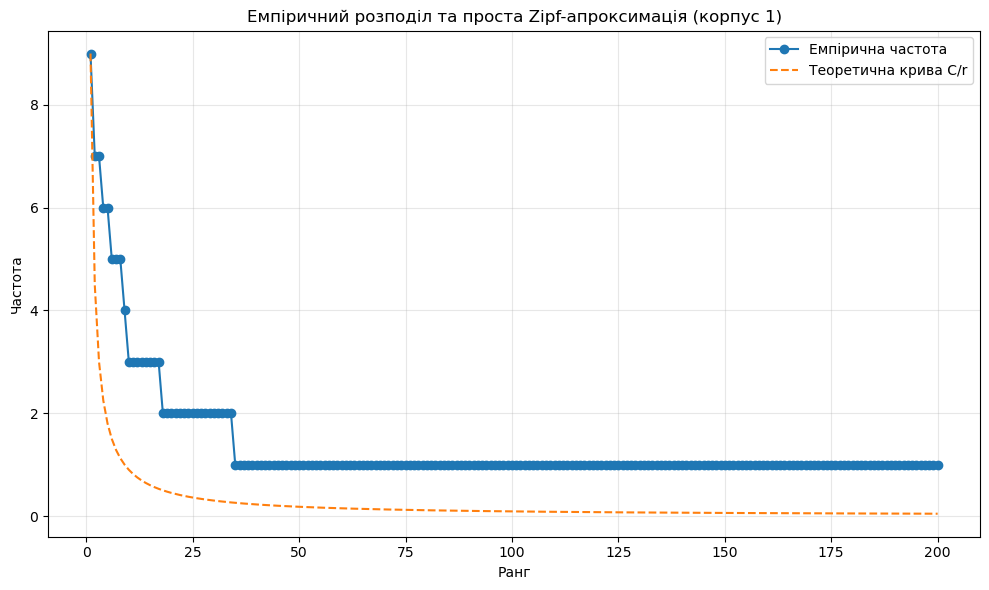

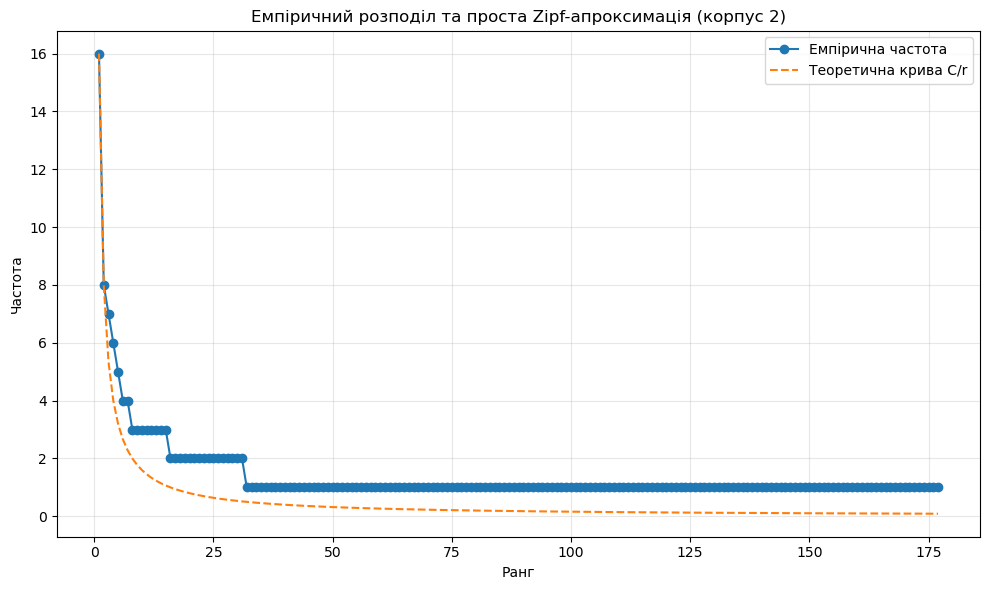

In [62]:
plt.figure(figsize=(10, 6))
plt.plot(freq_df_1["rank"], freq_df_1["abs_freq"], marker="o", label="Емпірична частота")
plt.plot(freq_df_1["rank"], freq_df_1["zipf_theoretical"], linestyle="--", label="Теоретична крива C/r")
plt.xlabel("Ранг")
plt.ylabel("Частота")
plt.title("Емпіричний розподіл та проста Zipf-апроксимація (корпус 1)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
plt.plot(freq_df_2["rank"], freq_df_2["abs_freq"], marker="o", label="Емпірична частота")
plt.plot(freq_df_2["rank"], freq_df_2["zipf_theoretical"], linestyle="--", label="Теоретична крива C/r")
plt.xlabel("Ранг")
plt.ylabel("Частота")
plt.title("Емпіричний розподіл та проста Zipf-апроксимація (корпус 2)")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Інформаційна характеристика корпусів: ентропія Шеннона

Ентропія вища у першого корпусу, бо він має рівномірніший розподіл частот.


In [64]:
def create_entropy_df(analysis_corpus):
    all_tokens = [token for doc in analysis_corpus for token in doc]
    token_counter = Counter(all_tokens)

    freq_values = np.array(list(token_counter.values()), dtype=float)
    probabilities = freq_values / freq_values.sum()

    entropy = -np.sum(probabilities * np.log2(probabilities))
    max_entropy = np.log2(len(probabilities)) if len(probabilities) > 0 else 0
    normalized_entropy = entropy / max_entropy if max_entropy > 0 else 0

    entropy_df = pd.DataFrame(
        {
            "Показник": [
                "Ентропія Шеннона H",
                "Максимально можлива ентропія log2(V)",
                "Нормована ентропія H / log2(V)",
            ],
            "Значення": [
                round(float(entropy), 4),
                round(float(max_entropy), 4),
                round(float(normalized_entropy), 4),
            ],
        }
    )

    return entropy_df

print("Корпус 1:")
display(create_entropy_df(tokenized_corpus))

print("Корпус 2:")
display(create_entropy_df(stemmed_corpus))


Корпус 1:


,Показник,Значення
0,Ентропія Шеннона H,7.3502
1,Максимально можлива ентропія log2(V),7.6439
2,Нормована ентропія H / log2(V),0.9616


Корпус 2:


,Показник,Значення
0,Ентропія Шеннона H,7.1010
1,Максимально можлива ентропія log2(V),7.4676
2,Нормована ентропія H / log2(V),0.9509


## 9. Інтерпретація результатів

Після виконання коду потрібно коротко проаналізувати отримані таблиці та графіки.  
У висновках варто відповісти щонайменше на такі питання:

1. Які слова стали найчастотнішими і чому саме вони?
2. Чи є в корпусі домінування окремої тематичної групи термінів?
3. Наскільки ранговий розподіл схожий на закон Ципфа?
4. Чи зростає словник сублінійно, як передбачає закон Хіпса?
5. Що говорить значення ентропії про лексичну різноманітність корпусу?

Для зручності нижче наведено шаблон короткого текстового висновку.


## Висновки

У ході виконання лабораторної роботи було опрацьовано основні методи того, як можна проаналізувати корпус текстів. Було обрано тексти на тему аналізу текстів та машинного навчання. Загалом було обрано 20 текстів в додачу до базового корпусу із 10 текстів.
Було побудовано два різні варіанти корпусу: зі стоп-словами та без стоп-слів. Словник без стоп-слів також був опрацьований стемінгом, тому слова втратили своє закінчення для об'єднання однакових за сенсом слів як одне.
Далі було виконано частотний аналіз для обох корпусів, і стало зрозуміло, що стоп-слова займають високі позиції у топі частоти, але при цьому за ними не можна легко зрозуміти, про що ці корпуса. Найчастіші чотири слова першого корпусу: "для", "навчання", "та", "текст". Найчастіші чотири слова другого корпусу: "текст", "навчання", "аналіз", "майнінг". Очевидно, що тема текстів ясніша саме по другому списку.
Через велику кількість частих слів, ентропія першого корпусу вища за другого, а отже він і гірше підходить за ранговим розподілом.


## Контрольні питання

1. Що таке абсолютна та відносна частота токена?
Абсолютна частота - це кількість появ токена в тексті, а відносна - його частка від загальної кількості токенів.
2. Для чого використовується ранговий частотний словник?
Ранговий частотний словник використовується для впорядкування слів за спаданням частоти та аналізу їх значущості.
3. У чому полягає зміст закону Ципфа?
Закон Ципфа стверджує, що частота слова обернено пропорційна його рангу у впорядкованому списку частот.
4. Чому у природних текстах виникає довгий хвіст рідкісних слів?
Довгий хвіст рідкісних слів виникає через велику різноманітність мовних форм, термінів і помилок у реальних текстах.
5. Що описує закон Хіпса?
Закон Хіпса описує залежність між розміром тексту і зростанням словникового запасу.
6. Чому зростання словника зазвичай є сублінійним?
Словник зростає сублінійно, бо нові слова з’являються дедалі рідше в міру збільшення тексту.
7. Що показує ентропія Шеннона для текстового корпусу?
Ентропія Шеннона показує рівень невизначеності або різноманітності символів чи слів у тексті.
8. Як видалення стоп-слів впливає на частотний аналіз?
Видалення стоп-слів зменшує шум і підсилює значущість змістовних слів у частотному аналізі.
9. Чому статистичні характеристики тексту важливі для подальшої векторизації?
Статистичні характеристики важливі, бо вони формують основу для векторних подань тексту в NLP-моделях.
10. Які обмеження має простий частотний аналіз?
Простий частотний аналіз обмежений тим, що не враховує контекст, порядок слів і семантику.
